# Аномалии в данных FHVHV (Uber/Lyft/Via/Juno), 2019–2024

Извлечено из `data_exploration.ipynb` (раздел 17). Анализ ~27 ГБ помесячных parquet-файлов `TLC_Trip_Data/fhvhv/` через DuckDB-агрегацию поверх файлов на диске, с проверкой целостности (файлы могли докачиваться в фоне) и визуализацией динамики аномалий по месяцам.


## 17. Данные FHVHV (агрегаторы такси Uber/Lyft/Via/Juno, 2019–2024): поиск аномалий

В `TLC_Trip_Data/fhvhv/` лежат помесячные файлы поездок high-volume for-hire vehicles (`hvfhs_license_num`: HV0002=Juno, HV0003=Uber, HV0004=Via, HV0005=Lyft) — суммарно ~27 ГБ, 66+ файлов с 2019-02 по 2024-08.

**Подход:** загружать всё в pandas нецелесообразно (десятки миллионов строк в месяц). Вместо этого агрегируем через DuckDB прямо поверх parquet-файлов на диске — читаем каждый файл потоково, без полной загрузки в память, и на выходе получаем компактную таблицу «месяц × число аномалий».

**Важно:** папка с файлами докачивается в реальном времени (в момент анализа на диске появлялись новые файлы, а последний файл был не дописан). Поэтому перед сканированием каждый файл проверяется на целостность (parquet-файлы заканчиваются магическими байтами `PAR1`) — недокачанные файлы пропускаются, а не роняют весь запрос.

In [1]:
import glob as globmod
import duckdb


def is_complete_parquet(path):
    try:
        with open(path, "rb") as fh:
            fh.seek(-4, 2)
            return fh.read(4) == b"PAR1"
    except OSError:
        return False


fhvhv_pattern = "TLC_Trip_Data/fhvhv/*.parquet"
all_fhvhv_files = sorted(globmod.glob(fhvhv_pattern))
good_fhvhv_files = [f for f in all_fhvhv_files if is_complete_parquet(f)]
skipped_fhvhv_files = sorted(set(all_fhvhv_files) - set(good_fhvhv_files))

print(f"Найдено файлов: {len(all_fhvhv_files)}, целых: {len(good_fhvhv_files)}, пропущено (не докачаны): {len(skipped_fhvhv_files)}")
if skipped_fhvhv_files:
    print("Пропущены:", skipped_fhvhv_files)

Найдено файлов: 72, целых: 71, пропущено (не докачаны): 1
Пропущены: ['TLC_Trip_Data/fhvhv\\fhvhv_tripdata_2025-01.parquet']


In [2]:
con = duckdb.connect()
con.execute("PRAGMA threads=8")

fhvhv_sql = """
WITH src AS (
    SELECT
        strftime(pickup_datetime, '%Y-%m') AS pickup_month,
        hvfhs_license_num, originating_base_num,
        request_datetime, on_scene_datetime, pickup_datetime, dropoff_datetime,
        PULocationID, DOLocationID,
        trip_miles, trip_time,
        base_passenger_fare, tolls, bcf, sales_tax, congestion_surcharge, airport_fee, tips, driver_pay
    FROM read_parquet($files, union_by_name=True)
)
SELECT
    pickup_month,
    count(*) AS n_trips,

    sum(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) AS null_originating_base,
    sum(CASE WHEN congestion_surcharge IS NULL THEN 1 ELSE 0 END) AS null_congestion_surcharge,
    sum(CASE WHEN airport_fee IS NULL THEN 1 ELSE 0 END) AS null_airport_fee,

    sum(CASE WHEN trip_miles <= 0 THEN 1 ELSE 0 END) AS trip_miles_le0,
    sum(CASE WHEN trip_miles > 100 THEN 1 ELSE 0 END) AS trip_miles_gt100,
    sum(CASE WHEN trip_time <= 0 THEN 1 ELSE 0 END) AS trip_time_le0,
    sum(CASE WHEN trip_time > 10800 THEN 1 ELSE 0 END) AS trip_time_gt3h,

    sum(CASE WHEN dropoff_datetime <= pickup_datetime THEN 1 ELSE 0 END) AS dropoff_le_pickup,
    sum(CASE WHEN on_scene_datetime < request_datetime THEN 1 ELSE 0 END) AS onscene_lt_request,
    sum(CASE WHEN pickup_datetime < request_datetime THEN 1 ELSE 0 END) AS pickup_lt_request,
    sum(CASE WHEN abs(date_diff('second', pickup_datetime, dropoff_datetime) - trip_time) > 60 THEN 1 ELSE 0 END) AS duration_mismatch_gt60s,

    sum(CASE WHEN base_passenger_fare < 0 THEN 1 ELSE 0 END) AS fare_lt0,
    sum(CASE WHEN driver_pay < 0 THEN 1 ELSE 0 END) AS driver_pay_lt0,
    sum(CASE WHEN driver_pay = 0 THEN 1 ELSE 0 END) AS driver_pay_eq0,

    sum(CASE WHEN PULocationID NOT BETWEEN 1 AND 265 THEN 1 ELSE 0 END) AS pu_zone_out_of_range,
    sum(CASE WHEN DOLocationID NOT BETWEEN 1 AND 265 THEN 1 ELSE 0 END) AS do_zone_out_of_range,
    sum(CASE WHEN hvfhs_license_num NOT IN ('HV0002','HV0003','HV0004','HV0005') THEN 1 ELSE 0 END) AS bad_license_num
FROM src
GROUP BY pickup_month
ORDER BY pickup_month
"""

fhvhv_anom = con.execute(fhvhv_sql, {"files": good_fhvhv_files}).df()
fhvhv_anom["pickup_month"] = pd.to_datetime(fhvhv_anom["pickup_month"])
print(f"Месяцев: {len(fhvhv_anom)}, всего поездок: {fhvhv_anom['n_trips'].sum():,}")
fhvhv_anom.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

NameError: name 'pd' is not defined

In [ ]:
anomaly_cols = [c for c in fhvhv_anom.columns if c not in ("pickup_month", "n_trips")]
total_trips = fhvhv_anom["n_trips"].sum()

summary = pd.DataFrame({
    "count": fhvhv_anom[anomaly_cols].sum(),
    "pct_of_all_trips": (fhvhv_anom[anomaly_cols].sum() / total_trips * 100).round(3),
}).sort_values("count", ascending=False)
summary

,count,pct_of_all_trips
null_airport_fee,414435054.0,34.086
null_originating_base,330279848.0,27.165
driver_pay_eq0,36436667.0,2.997
onscene_lt_request,10895716.0,0.896
duration_mismatch_gt60s,9477821.0,0.780
pickup_lt_request,8790167.0,0.723
fare_lt0,1279812.0,0.105
trip_miles_le0,834796.0,0.069
null_congestion_surcharge,513041.0,0.042
trip_miles_gt100,120623.0,0.010


### Динамика аномалий во времени

Пять панелей ниже показывают самые содержательные закономерности: эволюцию схемы данных (поля, которые раньше не заполнялись), выброс в ноябре (перевод часов), рост логических нарушений порядка событий и снижение доли отрицательных сумм.

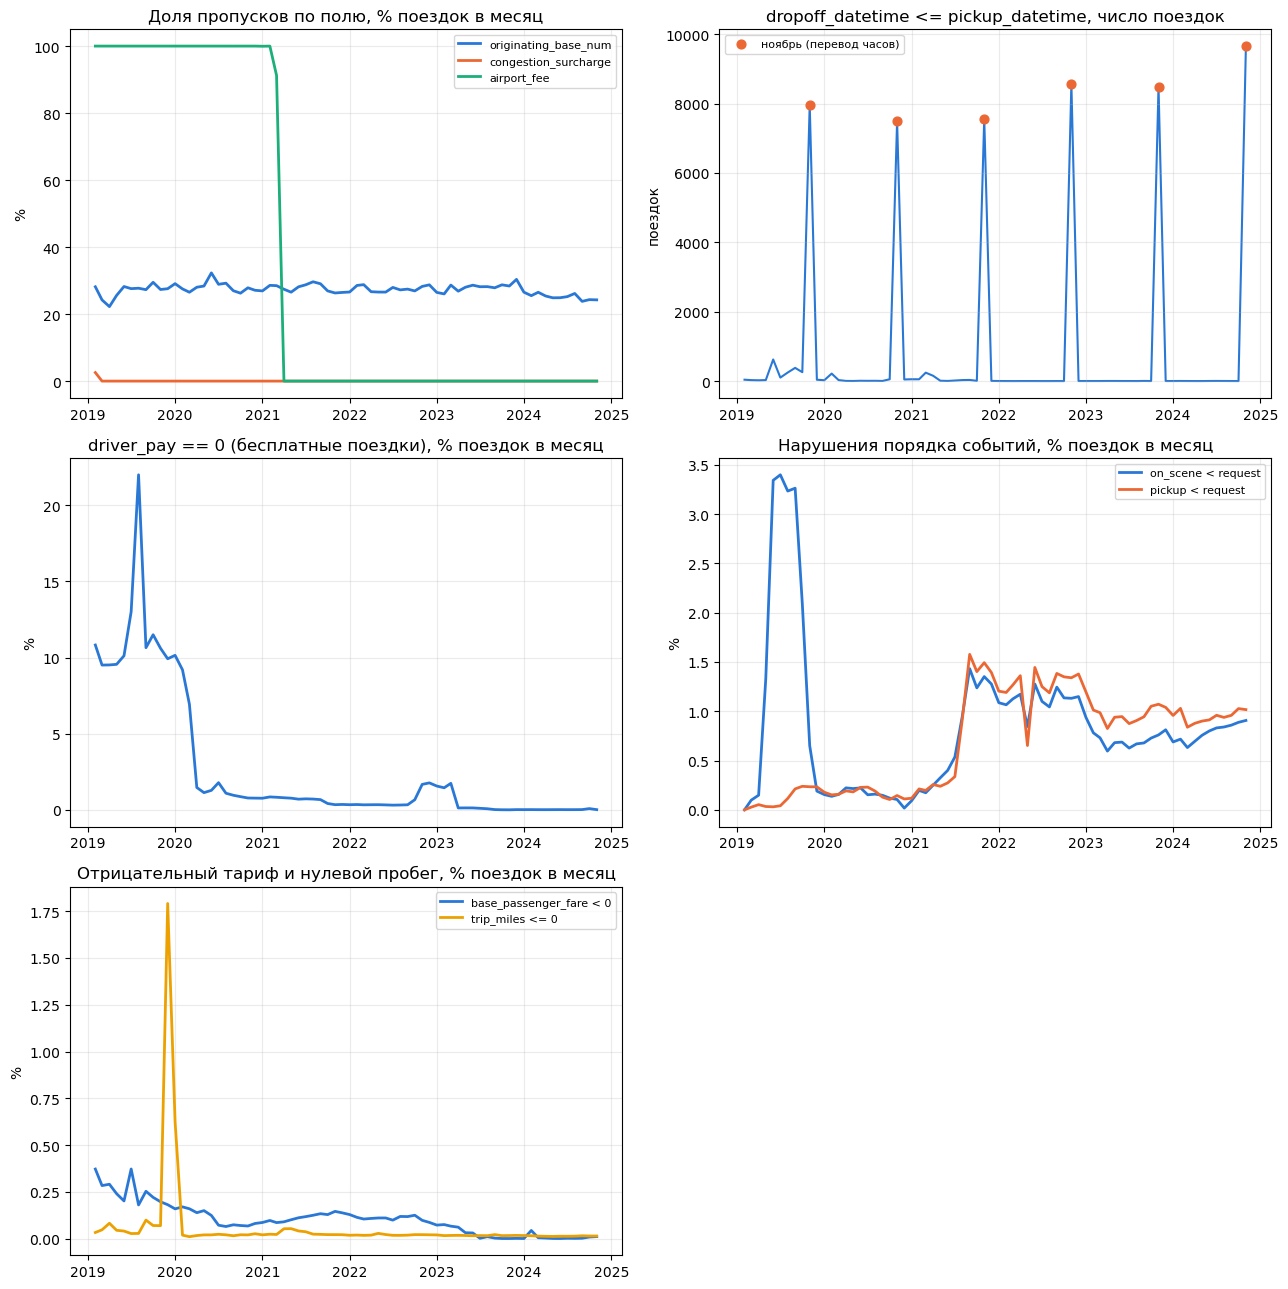

In [ ]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"

fhvhv_anom["pct_null_originating_base"] = fhvhv_anom["null_originating_base"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["pct_null_congestion_surcharge"] = fhvhv_anom["null_congestion_surcharge"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["pct_null_airport_fee"] = fhvhv_anom["null_airport_fee"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["pct_driver_pay_eq0"] = fhvhv_anom["driver_pay_eq0"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["pct_onscene_lt_request"] = fhvhv_anom["onscene_lt_request"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["pct_pickup_lt_request"] = fhvhv_anom["pickup_lt_request"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["pct_fare_lt0"] = fhvhv_anom["fare_lt0"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["pct_trip_miles_le0"] = fhvhv_anom["trip_miles_le0"] / fhvhv_anom["n_trips"] * 100
fhvhv_anom["is_november"] = fhvhv_anom["pickup_month"].dt.month == 11

fig, axes = plt.subplots(3, 2, figsize=(13, 13))

ax = axes[0, 0]
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_null_originating_base"], color=BLUE, lw=2, label="originating_base_num")
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_null_congestion_surcharge"], color=ORANGE, lw=2, label="congestion_surcharge")
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_null_airport_fee"], color=AQUA, lw=2, label="airport_fee")
ax.set_title("Доля пропусков по полю, % поездок в месяц")
ax.set_ylabel("%")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["dropoff_le_pickup"], color=BLUE, lw=1.5, zorder=1)
nov = fhvhv_anom[fhvhv_anom["is_november"]]
ax.scatter(nov["pickup_month"], nov["dropoff_le_pickup"], color=ORANGE, s=40, zorder=2, label="ноябрь (перевод часов)")
ax.set_title("dropoff_datetime <= pickup_datetime, число поездок")
ax.set_ylabel("поездок")
ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_driver_pay_eq0"], color=BLUE, lw=2)
ax.set_title("driver_pay == 0 (бесплатные поездки), % поездок в месяц")
ax.set_ylabel("%")

ax = axes[1, 1]
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_onscene_lt_request"], color=BLUE, lw=2, label="on_scene < request")
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_pickup_lt_request"], color=ORANGE, lw=2, label="pickup < request")
ax.set_title("Нарушения порядка событий, % поездок в месяц")
ax.set_ylabel("%")
ax.legend(fontsize=8)

ax = axes[2, 0]
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_fare_lt0"], color=BLUE, lw=2, label="base_passenger_fare < 0")
ax.plot(fhvhv_anom["pickup_month"], fhvhv_anom["pct_trip_miles_le0"], color=YELLOW, lw=2, label="trip_miles <= 0")
ax.set_title("Отрицательный тариф и нулевой пробег, % поездок в месяц")
ax.set_ylabel("%")
ax.legend(fontsize=8)

axes[2, 1].axis("off")

for a in axes.flat:
    a.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


### Выводы по FHVHV

- **`airport_fee` пропущен у 35.2% всех поездок за весь период, `originating_base_num` — у 27.3%.** Это два самых массовых "пропуска" в датасете, но оба объясняются эволюцией схемы: `airport_fee` был полностью пустым до начала 2021 года (колонки физически не существовало в старом формате), а `originating_base_num`, судя по всему, по дизайну заполняется не всегда (стабильные ~25-30% пропусков в каждом месяце все 5.5 лет, а не разовый сбой).
- **`congestion_surcharge` пропущен только в первый месяц выборки** (2019-02, ~2.5%) — сбор был введён именно тогда.
- **`driver_pay == 0` ("бесплатные" поездки) — третья по величине аномалия (36.4 млн поездок, 3.1% за весь период), и она резко концентрируется в начале выборки:** в феврале 2019 таких поездок было ~10.8%, и доля стабильно падала, опустившись до ~0.02% к 2023–2024. Похоже на проблему сопоставления данных о выплатах водителю на старте программы HVFHS, устранённую со временем — а не на текущий источник ошибок.
- **Выброс `dropoff_datetime <= pickup_datetime` каждый ноябрь** — заметный скачок числа таких записей повторяется из года в год именно в ноябре (2019-2023), что совпадает с переводом часов на зимнее время в США (сдвиг на час назад создаёт неоднозначность локальных меток времени возле 2:00 ночи).
- **Растущая доля логических нарушений порядка событий** (`on_scene_datetime < request_datetime`, `pickup_datetime < request_datetime`, т.е. машина "приезжает"/забирает пассажира раньше, чем был сделан запрос): с околонулевых значений в 2019 году доля выросла до ~1-1.3% поездок в 2022-2023 — стоит проверить у источника, не сбой ли это конкретных диспетчерских систем.
- **Отрицательный `base_passenger_fare`** стабильно снижается — с ~0.4% поездок в 2019 до ~0.002% в 2023-2024, то есть качество данных по тарифу со временем улучшилось.
- **`trip_miles == 0` резко подскочил в декабре 2019 - январе 2020** (1.8% и 0.6% против обычных 0.01-0.1%) — точечная аномалия, вероятно сбой на стороне конкретного вендора/периода.
- **Зоны (`PULocationID`/`DOLocationID`) и коды лицензий (`hvfhs_license_num`) полностью валидны** во всех проверенных строках — по этим полям аномалий не найдено.